In [1]:
# Install libraries if not already present
!pip install pandas scikit-learn hdfs pyarrow joblib

import pandas as pd
import io
from hdfs import InsecureClient
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Configuration
HDFS_URL = "http://localhost:9870"
GOLD_PATH = "/data/tmp/rvl-cdip-gold/enriched_data.parquet"
MODEL_SAVE_PATH = "document_classifier.pkl"
VECTORIZER_SAVE_PATH = "tfidf_vectorizer.pkl"


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
client = InsecureClient(HDFS_URL, user='root')

print("Loading Enriched Gold Data from HDFS...")
with client.read(GOLD_PATH) as reader:
    df = pd.read_parquet(io.BytesIO(reader.read()))

print(f"✅ Success! Total Rows Loaded: {len(df)}")

# VISUAL CHECK: Show the category and the extracted text for the first 5 documents
print("\n--- DATA PREVIEW (Gold Layer) ---")
display(df[['category', 'ocr_text']].head())

Loading Enriched Gold Data from HDFS...
✅ Success! Total Rows Loaded: 4000

--- DATA PREVIEW (Gold Layer) ---


,category,ocr_text
0,file_folder,© CS - Current Transfer Lists
1,news_article,", 350th Anniversary 1993539929 — Jamestown to..."
2,budget,ccoeccececececeececececce’ «
3,file_folder,
4,form,REVISED The Fate of Chavis and OR PRESENTATIO...


In [3]:
# Remove nulls or empty strings
initial_count = len(df)
df = df.dropna(subset=['ocr_text'])
df = df[df['ocr_text'].str.strip() != ""]

print(f"Initially loaded: {initial_count} documents")
print(f"Cleaned documents (with valid text): {len(df)}")
print(f"Documents removed (OCR failures): {initial_count - len(df)}")

# VISUAL CHECK: Show a sample of the cleaned text
print("\n--- CLEANED TEXT SAMPLE ---")
print(df['ocr_text'].iloc[0][:200] + "...") # Show first 200 characters of the first row

Initially loaded: 4000 documents
Cleaned documents (with valid text): 3858
Documents removed (OCR failures): 142

--- CLEANED TEXT SAMPLE ---
© CS - Current Transfer Lists...


In [4]:
print("Vectorizing text using TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X = vectorizer.fit_transform(df['ocr_text'])
y = df['label']

print(f"✅ Text transformed into numerical matrix!")
print(f"Feature matrix size: {X.shape} (Documents x Vocabulary Words)")

Vectorizing text using TF-IDF...
✅ Text transformed into numerical matrix!
Feature matrix size: (3858, 5000) (Documents x Vocabulary Words)


In [5]:
from sklearn.model_selection import cross_val_score, KFold

# 1. Prepare data using official splits
train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

# 2. Vectorize the Training Text
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train_df['ocr_text'])
y_train = train_df['label']

# 3. Initialize K-Fold (e.g., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# 4. Perform Cross-Validation on the Train set
print(f"🚀 Starting 5-Fold Cross-Validation on {len(train_df)} training samples...")
cv_scores = cross_val_score(model, X_train, y_train, cv=kf)

print(f"\n--- K-FOLD RESULTS ---")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} Accuracy: {score * 100:.2f}%")

print(f"\nAverage Training Accuracy: {cv_scores.mean() * 100:.2f}%")

# 5. Final Training and Blind Test
model.fit(X_train, y_train)
X_test = vectorizer.transform(test_df['ocr_text'])
y_test = test_df['label']

final_accuracy = model.score(X_test, y_test)
print(f"\n✅ Final Blind Test Accuracy: {final_accuracy * 100:.2f}%")

🚀 Starting 5-Fold Cross-Validation on 3091 training samples...

--- K-FOLD RESULTS ---
Fold 1 Accuracy: 60.10%
Fold 2 Accuracy: 64.24%
Fold 3 Accuracy: 63.11%
Fold 4 Accuracy: 59.55%
Fold 5 Accuracy: 60.68%

Average Training Accuracy: 61.53%

✅ Final Blind Test Accuracy: 61.98%


In [6]:
y_pred = model.predict(X_test)

print("--- CLASSIFICATION REPORT ---")
# This generates the table your mam will want to see
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.79      0.55      0.65        20
           1       0.58      0.58      0.58        26
           2       0.67      0.74      0.70        19
           3       0.37      0.41      0.39        17
           4       0.29      0.41      0.34        17
           5       0.50      0.32      0.39        28
           6       0.74      0.68      0.71        25
           7       0.87      0.72      0.79        18
           8       0.37      0.90      0.53        21
           9       0.56      0.45      0.50        20
          10       0.71      0.56      0.62        36
          11       0.65      0.60      0.62        25
          12       0.67      0.44      0.53        27
          13       0.77      0.82      0.79        28
          14       0.96      0.85      0.90        26
          15       0.71      0.81      0.76        31

    accuracy                           0.62       

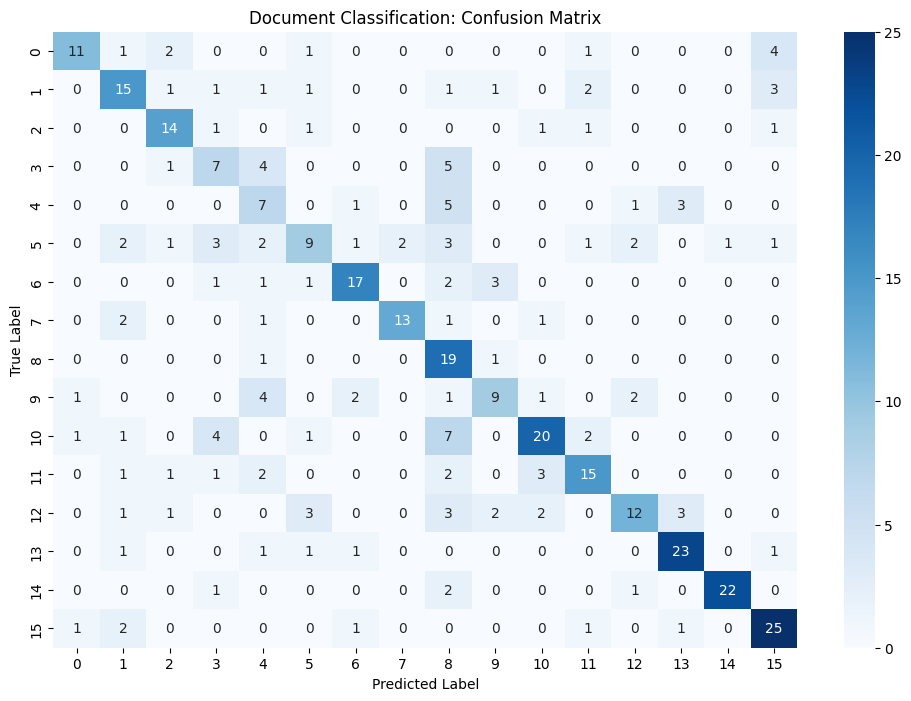

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Document Classification: Confusion Matrix')
plt.show()

In [9]:
# Create a dynamic mapping from your HDFS data
mapping_df = df[['label', 'category']].drop_duplicates().sort_values('label')
categories = mapping_df['category'].tolist()

print("Mapped categories from HDFS:")
print(categories)

Mapped categories from HDFS:
['letter', 'form', 'email', 'handwritten', 'advertisement', 'scientific_report', 'scientific_publication', 'specification', 'file_folder', 'news_article', 'budget', 'invoice', 'presentation', 'questionnaire', 'resume', 'memo']


In [12]:
# 2. Select 5 random samples from the test set
test_samples = test_df.sample(5)

print("--- LIVE TEST RESULTS ---")
for i, row in test_samples.iterrows():
    # Transform the text using our trained vectorizer
    sample_vector = vectorizer.transform([row['ocr_text']])
    
    # Predict the label (integer)
    pred_label = model.predict(sample_vector)[0]
    
    # Get names for display
    actual_cat = row['category']
    # Use the dynamic list to find the predicted category name
    predicted_cat = categories[pred_label]
    
    # Extract filename from the HDFS path for the PPT visual
    doc_name = row['image_path'].split('/')[-1]
    
    print(f"File: {doc_name}")
    print(f"Actual Category: {actual_cat.upper()}")
    print(f"AI Prediction:   {predicted_cat.upper()}")
    print(f"Status: {'✅ MATCH' if actual_cat == predicted_cat else '❌ MISMATCH'}")
    print("-" * 40)

--- LIVE TEST RESULTS ---
File: img_34.jpg
Actual Category: BUDGET
AI Prediction:   BUDGET
Status: ✅ MATCH
----------------------------------------
File: img_29.jpg
Actual Category: BUDGET
AI Prediction:   BUDGET
Status: ✅ MATCH
----------------------------------------
File: img_74.jpg
Actual Category: EMAIL
AI Prediction:   EMAIL
Status: ✅ MATCH
----------------------------------------
File: img_305.jpg
Actual Category: RESUME
AI Prediction:   RESUME
Status: ✅ MATCH
----------------------------------------
File: img_95.jpg
Actual Category: FILE_FOLDER
AI Prediction:   FILE_FOLDER
Status: ✅ MATCH
----------------------------------------


In [13]:
# Save the model and the vectorizer
joblib.dump(model, MODEL_SAVE_PATH)
joblib.dump(vectorizer, VECTORIZER_SAVE_PATH)

print(f"Model saved as {MODEL_SAVE_PATH}")
print(f"Vectorizer saved as {VECTORIZER_SAVE_PATH}")

Model saved as document_classifier.pkl
Vectorizer saved as tfidf_vectorizer.pkl
